### Open the file

In [426]:
import numpy as np 
import pandas as pd
from datetime  import datetime

In [427]:
df = pd.read_csv("Listings.csv",encoding="ISO-8859-1")

/var/folders/92/jpt988fd0g92rw2ncx16x0fr0000gn/T/ipykernel_76588/1471175929.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Listings.csv",encoding="ISO-8859-1")


In [428]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [429]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

### Cast any date columns as a datetime format

In [430]:
df["host_since"] = pd.to_datetime(df["host_since"], format="%Y-%m-%d")

### Filter the data down to rows where the city is Paris, and keep only the columns ‘host_since’, ‘neighbourhood’, ‘city’, ‘accommodates’, and ‘price’

In [431]:
new_df = df.loc[df['city']=='Paris',['host_since','neighbourhood','city','accommodates','price']]

In [432]:
new_df

,host_since,neighbourhood,city,accommodates,price
0,2011-12-03,Buttes-Montmartre,Paris,2,53
1,2013-11-29,Buttes-Montmartre,Paris,2,120
2,2014-07-31,Elysee,Paris,2,89
3,2013-12-17,Vaugirard,Paris,2,58
4,2014-12-14,Passy,Paris,2,60
...,...,...,...,...,...
279707,2015-04-13,Observatoire,Paris,2,120
279708,2013-11-27,Buttes-Montmartre,Paris,2,60
279709,2012-04-27,Buttes-Montmartre,Paris,2,50
279710,2015-07-16,Popincourt,Paris,2,105


### QA the Paris listings data: check for missing values, and calculate the minimum, maximum, and average for each numeric field

In [433]:
new_df.isnull().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [434]:
new_df=new_df.dropna(subset=["host_since"])

In [435]:
new_df.isnull().sum()

host_since       0
neighbourhood    0
city             0
accommodates     0
price            0
dtype: int64

In [436]:
new_df.describe()

,host_since,accommodates,price
count,64657,64657.000000,64657.000000
mean,2015-11-01 11:06:05.528867328,3.037877,113.104614
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588382,214.479626


In [437]:
(new_df["price"]==0).sum() 

np.int64(62)

In [438]:
new_df = df.drop(df[(df['price'] == 0) | (df['accommodates'] == 0)].index)

In [439]:
(new_df['price']==0).sum()

np.int64(0)

### Create a table named paris_listings_neighbourhood that groups Paris listings by 'neighbourhood' and calculates the mean price (sorted low to high)

In [440]:
new_df = df[df['city'].str.lower().str.strip() == 'paris']

In [441]:
Paris_listing_neighbourhood = (new_df
.groupby('neighbourhood')
.agg({'price':'mean'})
.sort_values('price')
)

In [442]:
Paris_listing_neighbourhood.head()

,price
neighbourhood,
Menilmontant,74.942257
Buttes-Chaumont,82.690182
Buttes-Montmartre,87.209479
Reuilly,89.058402
Popincourt,90.559459


### Create a table named paris_listings_accomodations, filter down to the most expensive neighborhood, group by the ‘accommodations’ column, and add the mean price for each value of ‘accommodates’ (sorted low to high)

In [443]:
top_neighboorhood = new_df.groupby('neighbourhood')['price'].mean().idxmax()
paris_listings_accomodations = (
    new_df.query("neighbourhood == @top_neighboorhood")
    .groupby('accommodates')['price'].mean()
    .sort_values(ascending=True)
    .reset_index()
)

paris_listings_accomodations.rename(columns={'price': 'mean_price'}, inplace=True)

In [444]:
paris_listings_accomodations.tail()

,accommodates,mean_price
11,12,529.625
12,16,800.000
13,11,805.000
14,13,842.500
15,14,971.000


In [445]:
top_neighboorhood

'Elysee'

### Create a table called paris_listings_over_time grouped by the ‘host_since’ year, and calculate the average price and count of rows representing the number of new hosts

In [446]:
paris_listings_over_time = (
    new_df.set_index("host_since")
    .resample('YE')
    .agg(
        average_price = ('price','mean'),
        new_hosts = ('price','count')
    )
   .reset_index() 
)

In [447]:
paris_listings_over_time

,host_since,average_price,new_hosts
0,2008-12-31,77.750000,4
1,2009-12-31,159.641509,106
2,2010-12-31,125.031250,416
3,2011-12-31,124.828230,1339
4,2012-12-31,111.578615,4592
5,2013-12-31,107.096414,8142
6,2014-12-31,100.253800,10922
7,2015-12-31,103.646250,12147
8,2016-12-31,114.159847,8871
9,2017-12-31,108.658888,4585


### Create a horizontal bar chart of the average price by neighborhood in Paris.

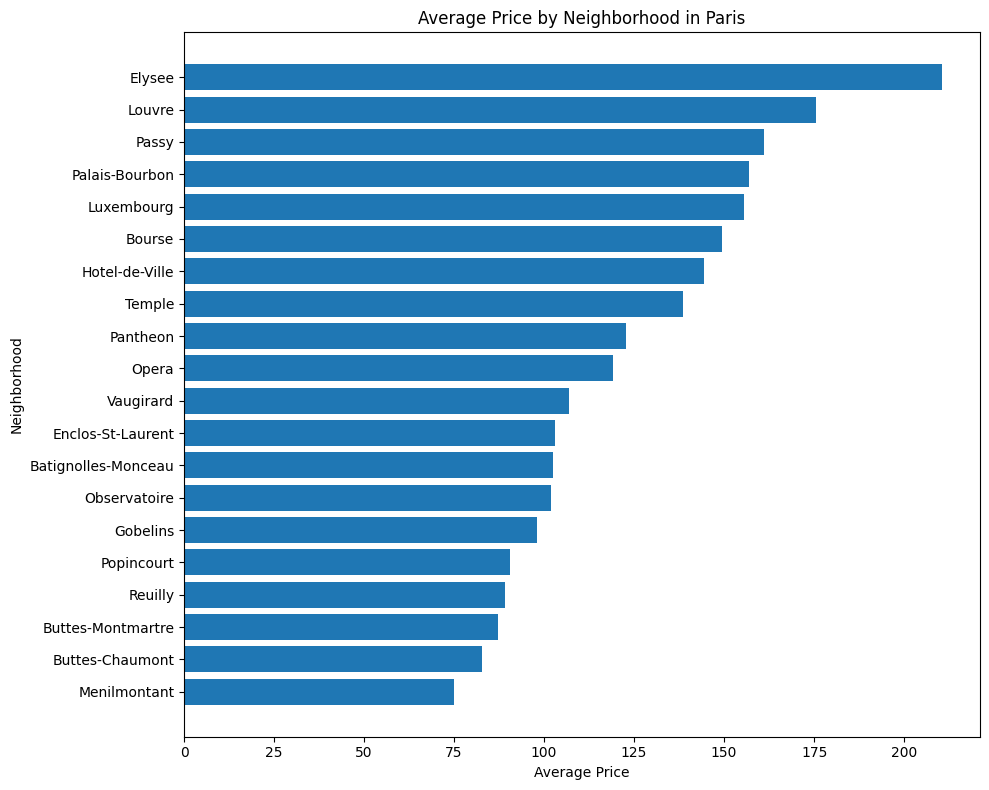

In [453]:
import matplotlib.pyplot as plt

# 1. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use barh for a horizontal chart. 
# Reference the index for the y-axis (neighborhoods) and the 'price' column for the x-axis.
ax.barh(Paris_listing_neighbourhood.index, Paris_listing_neighbourhood['price'])

# 3. Add essential, simple labels
ax.set_title("Average Price by Neighborhood in Paris")
ax.set_xlabel("Average Price")
ax.set_ylabel("Neighborhood")

# 4. Save the plot cleanly
plt.tight_layout()
plt.savefig("paris_neighborhoods_simple.png")

### Create a horizontal bar chart of the average price by ‘accommodates’ in Paris’ most expensive neighborhood, and make sure to add a title and change axis labels as needed

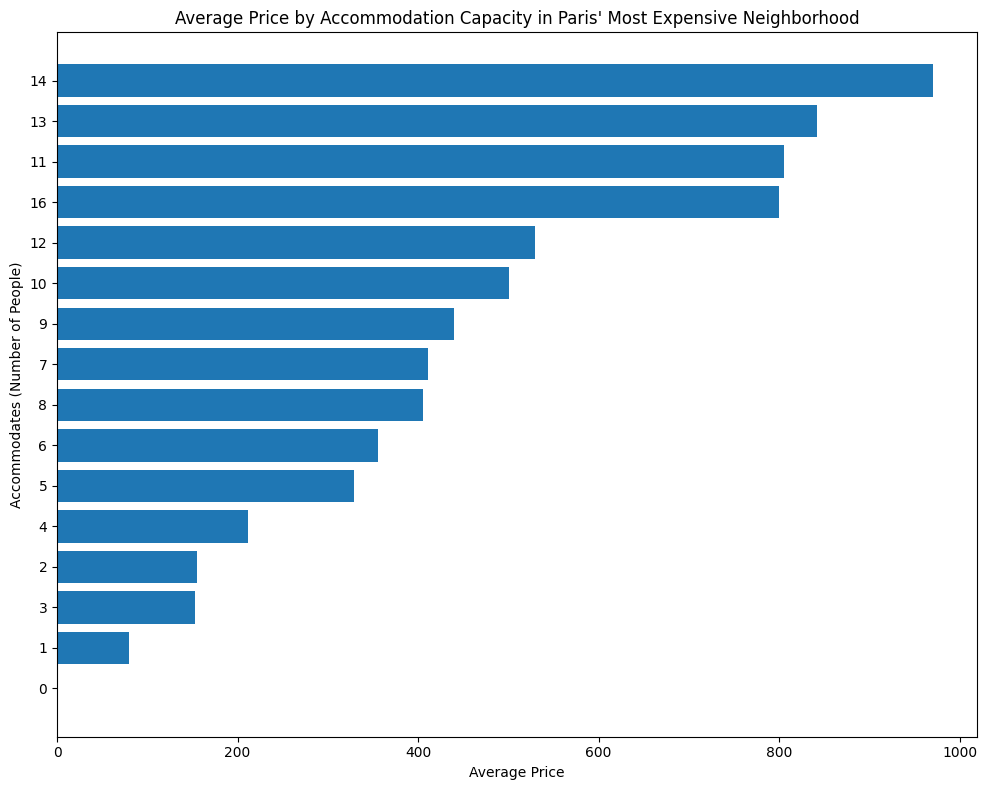

In [459]:

# 1. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 8))

# 2. Use barh for a horizontal chart. 
# Explicitly pass the 'accommodates' column for the y-axis and 'mean_price' for the x-axis.
# Note: Converting 'accommodates' to a string forces Matplotlib to treat it as a discrete category rather than a continuous number scale.
ax.barh(paris_listings_accomodations['accommodates'].astype(str), paris_listings_accomodations['mean_price'])

# 3. Add essential, simple labels
ax.set_title("Average Price by Accommodation Capacity in Paris' Most Expensive Neighborhood")
ax.set_xlabel("Average Price")
ax.set_ylabel("Accommodates (Number of People)")

# 4. Save the plot cleanly with an accurate filename
plt.tight_layout()
plt.savefig("paris_accommodations_price.png")

### Create two line charts: one showing the count of new hosts over time, and one showing average price. Set the y-axis limit to 0, add a title, and change axis labels as needed

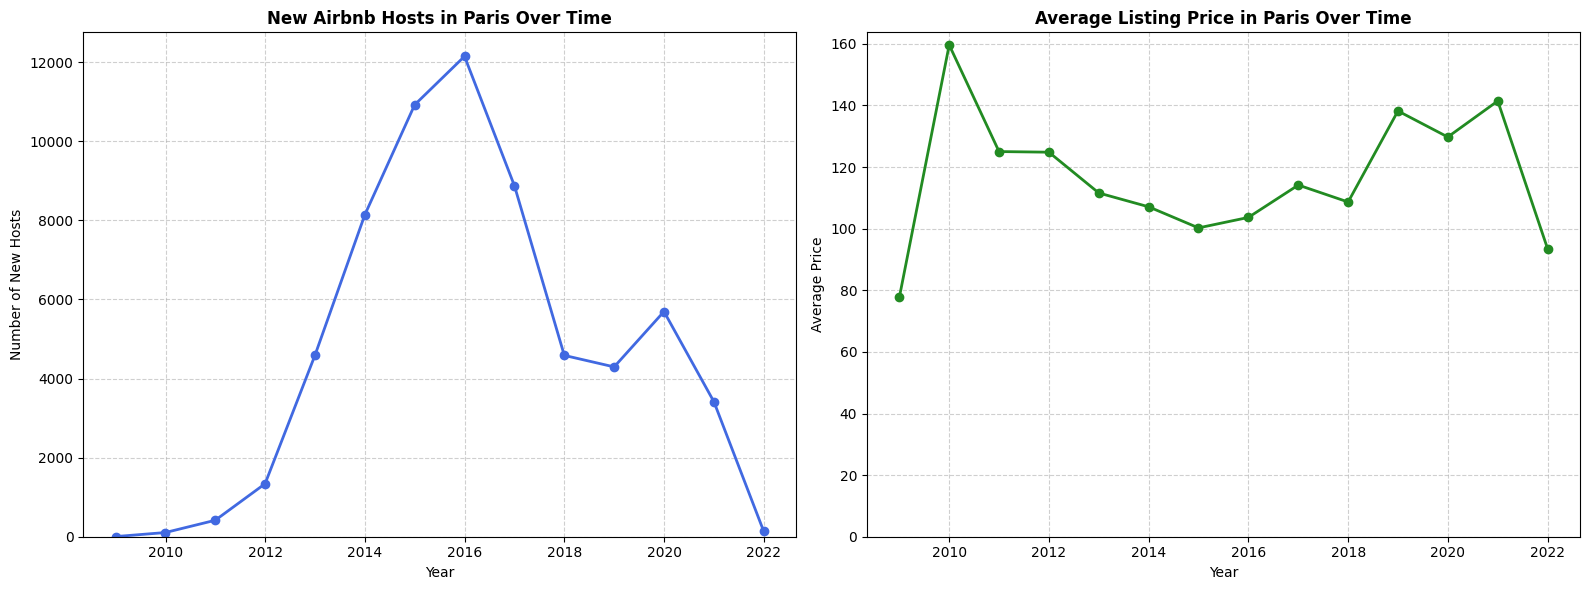

In [462]:
import matplotlib.pyplot as plt

# 1. Initialize the plot with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 2. Chart 1: Count of New Hosts Over Time
ax1.plot(paris_listings_over_time['host_since'], paris_listings_over_time['new_hosts'], color='royalblue', linewidth=2, marker='o')
ax1.set_title("New Airbnb Hosts in Paris Over Time", weight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of New Hosts")
ax1.set_ylim(bottom=0) # Forces the y-axis to start at 0
ax1.grid(True, linestyle="--", alpha=0.6)

# 3. Chart 2: Average Price Over Time
ax2.plot(paris_listings_over_time['host_since'], paris_listings_over_time['average_price'], color='forestgreen', linewidth=2, marker='o')
ax2.set_title("Average Listing Price in Paris Over Time", weight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Average Price")
ax2.set_ylim(bottom=0) # Forces the y-axis to start at 0
ax2.grid(True, linestyle="--", alpha=0.6)

# 4. Clean up layout and save
plt.tight_layout()
plt.savefig("paris_trends_over_time.png")

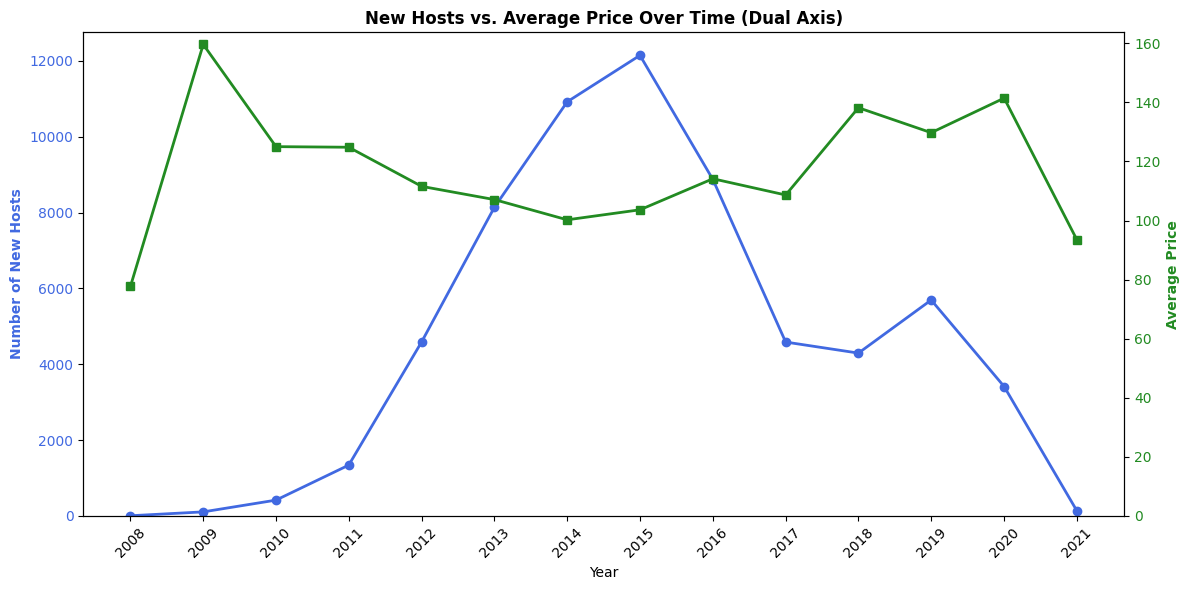

In [464]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))
years = paris_listings_over_time['host_since'].dt.year

# Axis 1: New Hosts (Left Y-Axis)
color_hosts = 'royalblue'
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of New Hosts', color=color_hosts, weight='bold')
ax1.plot(paris_listings_over_time['host_since'], paris_listings_over_time['new_hosts'], color=color_hosts, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color_hosts)
ax1.set_ylim(bottom=0)

# Format X-axis safely
ax1.set_xticks(paris_listings_over_time['host_since'])
ax1.set_xticklabels(years, rotation=45)

# Axis 2: Average Price (Right Y-Axis)
ax2 = ax1.twinx()  # This is the core function for a dual-axis chart
color_price = 'forestgreen'
ax2.set_ylabel('Average Price', color=color_price, weight='bold')
ax2.plot(paris_listings_over_time['host_since'], paris_listings_over_time['average_price'], color=color_price, marker='s', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color_price)
ax2.set_ylim(bottom=0)

# Final Output
plt.title("New Hosts vs. Average Price Over Time (Dual Axis)", weight="bold")
fig.tight_layout()
plt.savefig("paris_dual_axis_chart.png")